## Mall Customer Segmentation using Unsupervised Learning

##### Mall Customer Segmentation using Unsupervised Learning enables businesses to group customers with similar characteristics without predefined labels. By applying the K-Means clustering algorithm and evaluating the optimal number of clusters using the Elbow Method, organizations can identify valuable customer segments, personalize marketing strategies, improve customer satisfaction, and make informed business decisions. This project demonstrates how unsupervised machine learning can uncover hidden patterns in customer data and support effective business growth.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_excel("https://github.com/GeethaGunasekaran1/Dataset_rep/raw/refs/heads/main/mall_customer_spend.xlsx")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.shape

(200, 5)

In [3]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.dtypes

CustomerID                int64
Genre                       str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [7]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

In [10]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]]

In [11]:
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

In [12]:
intertia = []
for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42, n_init= 10)
    model.fit(X_scaler)
    intertia.append(model.inertia_)

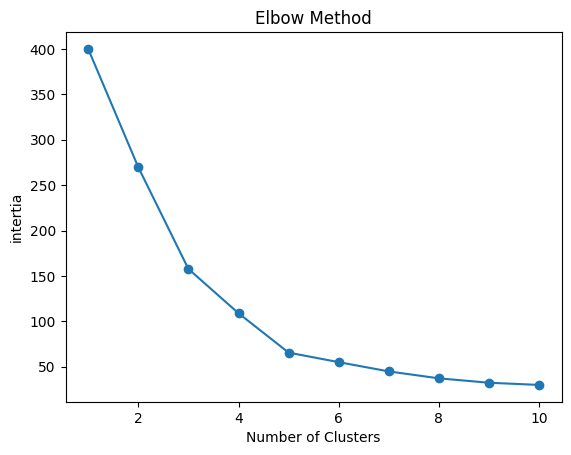

In [13]:
plt.plot(range(1,11), intertia, marker ='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("intertia")
plt.show()

In [15]:
kmeans = KMeans(n_clusters= 5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaler)

In [16]:
df["clusters"]= clusters

In [17]:
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   clusters  
0         4  
1         2  
2         4  
3         2  
4         4  


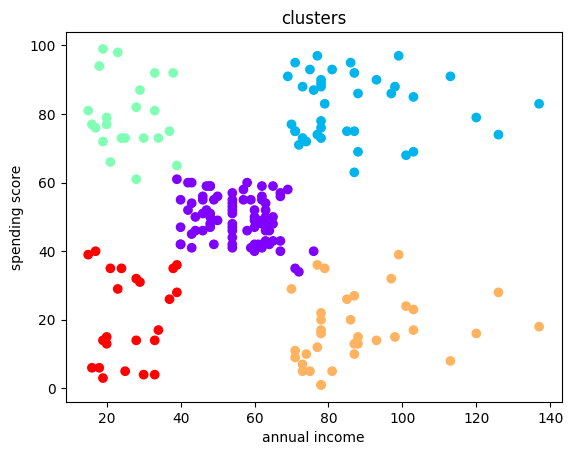

In [18]:
plt.scatter(X["Annual Income (k$)"],X["Spending Score (1-100)"], c = clusters, cmap= "rainbow")
plt.title("clusters")
plt.xlabel("annual income")
plt.ylabel("spending score")
plt.show()

In [19]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]]

In [20]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')

In [21]:
y_pred = hc.fit_predict(X)

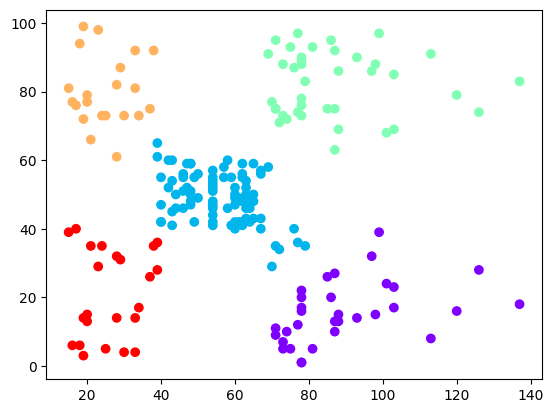

In [22]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_pred, cmap = "rainbow")
plt.show()


In [23]:
linkage = linkage(X, method='ward')

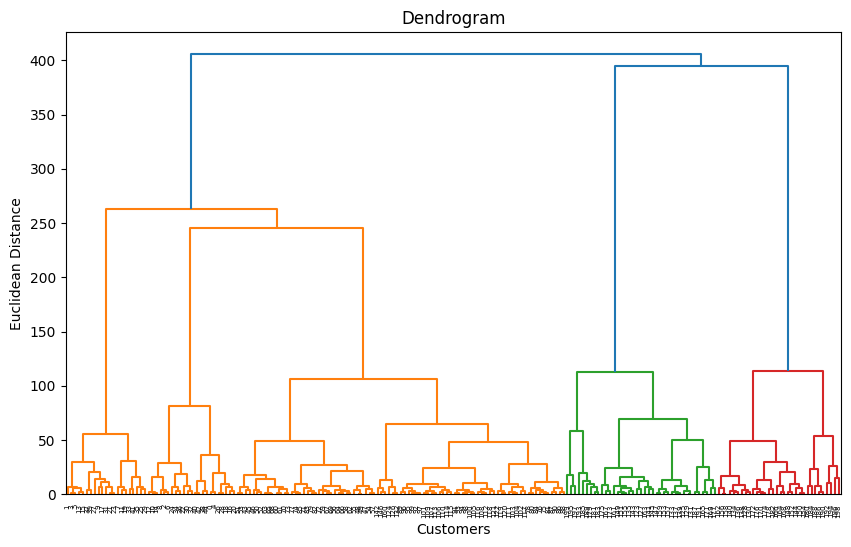

In [24]:
plt.figure(figsize=(10,6))
dendrogram(linkage)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [25]:
df = pd.read_excel("https://github.com/GeethaGunasekaran1/Dataset_rep/raw/refs/heads/main/mall_customer_spend.xlsx")

In [26]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [27]:
X_scaler

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [28]:
db = DBSCAN()

In [29]:
df ["Clustar_db"] = db.fit_predict(X_scaler)

In [30]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Clustar_db
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


In [31]:
df.Clustar_db.value_counts()

Clustar_db
 0    157
 1     35
-1      8
Name: count, dtype: int64

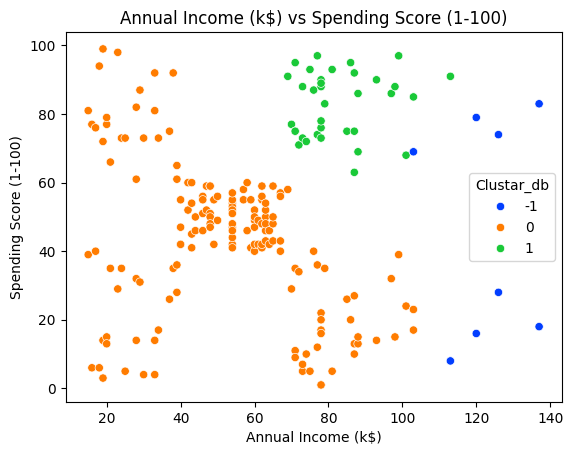

In [32]:
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", hue="Clustar_db", data=df, palette = "bright")
plt.title("Annual Income (k$) vs Spending Score (1-100)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

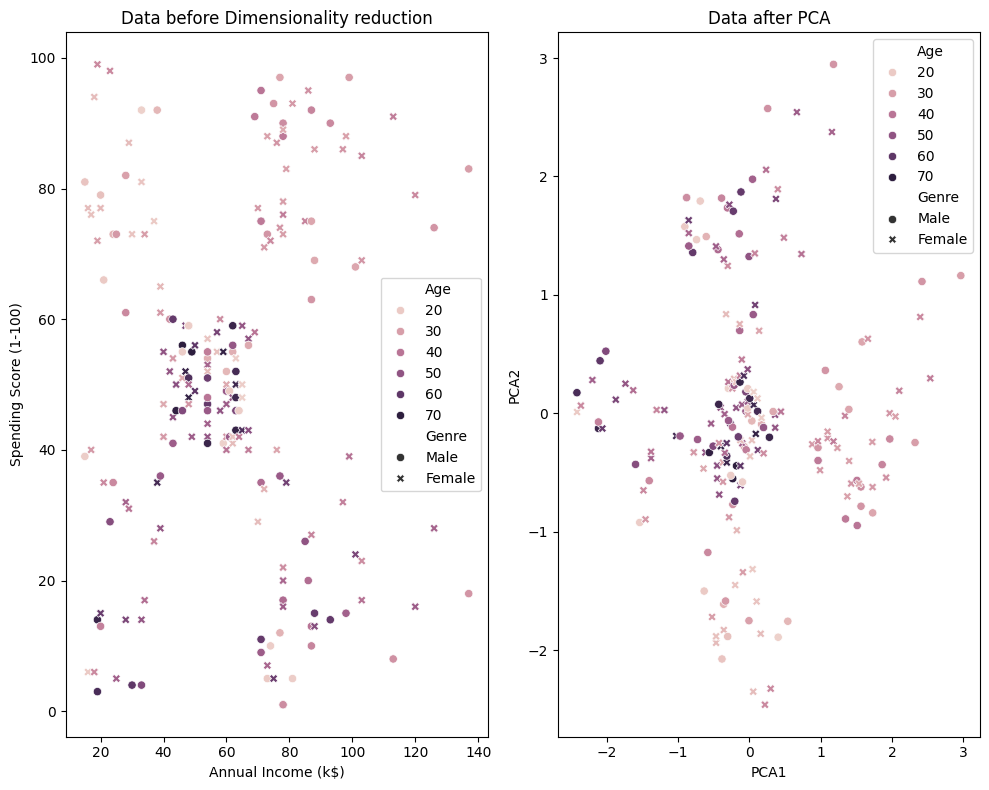

In [35]:
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Age", style="Genre", color = "green")
plt.title("Data before Dimensionality reduction")
plt.subplot(1,2,2)

plt.subplot(1,2,2)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaler)
df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Age", style="Genre")
plt.title("Data after PCA")
plt.tight_layout()
plt.show()


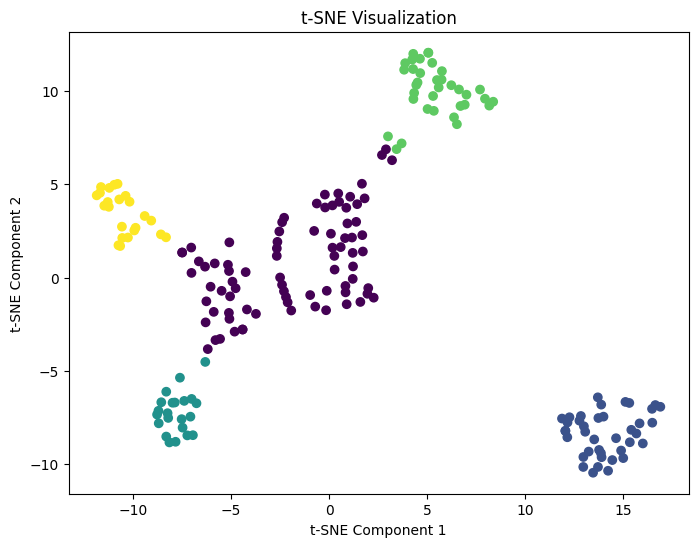

In [37]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2,random_state=42,perplexity=30)
X_tsne = tsne.fit_transform(X_scaler)
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=clusters,cmap='viridis')
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()
